In [17]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing,ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, root_mean_squared_error,mean_squared_error, r2_score

In [18]:
df= joblib.load(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl')

In [19]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,NaN,NaN,120.666667,10.263203,NaN,NaN,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,NaN,NaN,126.333333,7.371115,NaN,NaN,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,NaN,NaN,127.333333,5.686241,NaN,NaN,NaN,NaN


In [20]:
train= df.iloc[:-12,:]
test= df.iloc[-12:,:]

In [21]:
train.shape

(106, 14)

In [22]:
train= train.asfreq('MS')

In [23]:
test= test.asfreq('MS')

In [24]:
simple_model= SimpleExpSmoothing(train['#Passengers'].ffill()).fit()

In [25]:
simple_model.summary()

Dep. Variable:,#Passengers,No. Observations:,128
Model:,SimpleExpSmoothing,SSE,122413.001
Optimized:,True,AIC,882.480
Trend:,None,BIC,888.184
Seasonal:,None,AICC,882.805
Seasonal Periods:,None,Date:,"Sat, 08 Aug 2026"
Box-Cox:,False,Time:,09:33:36
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
initial_level,112.00000,l.0,False


In [26]:
simple_pred= simple_model.forecast(len(test))

In [27]:
simple_pred

1959-09-01    559.0
1959-10-01    559.0
1959-11-01    559.0
1959-12-01    559.0
1960-01-01    559.0
1960-02-01    559.0
1960-03-01    559.0
1960-04-01    559.0
1960-05-01    559.0
1960-06-01    559.0
1960-07-01    559.0
1960-08-01    559.0
1960-09-01    559.0
1960-10-01    559.0
1960-11-01    559.0
1960-12-01    559.0
Freq: MS, dtype: float64

In [28]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')

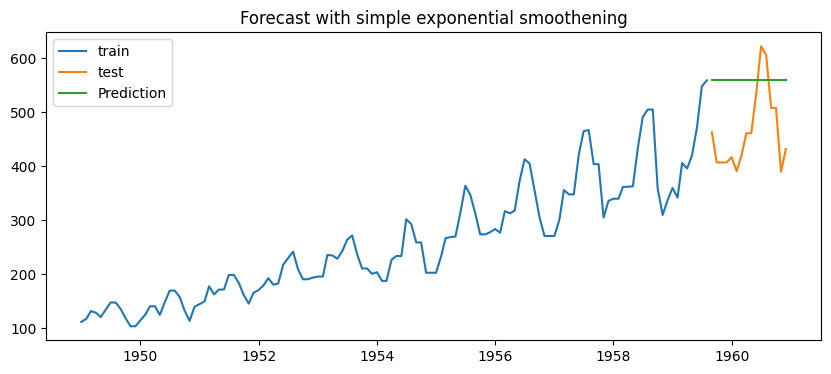

mean absolute error: 108.12
mean absolute percentage error: 25.0%
r2 score: -1.78
root mean squared error: 117.89


In [29]:
model_evaluator(train['#Passengers'].ffill(),test['#Passengers'].ffill(),simple_pred, 'simple exponential smoothening')

In [30]:
#  Double model

double_smoothening= ExponentialSmoothing(train['#Passengers'].ffill(),
                                         seasonal=None,
                                         trend='add',
                                         ).fit()

In [31]:
double_smoothening.summary()

Dep. Variable:,#Passengers,No. Observations:,128
Model:,ExponentialSmoothing,SSE,120839.702
Optimized:,True,AIC,884.824
Trend:,Additive,BIC,896.232
Seasonal:,None,AICC,885.519
Seasonal Periods:,None,Date:,"Sat, 08 Aug 2026"
Box-Cox:,False,Time:,09:34:09
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,0.000000,beta,True


In [32]:
double_pred= double_smoothening.forecast(len(test))

In [33]:
double_pred

1959-09-01    562.519688
1959-10-01    566.039377
1959-11-01    569.559065
1959-12-01    573.078753
1960-01-01    576.598442
1960-02-01    580.118130
1960-03-01    583.637819
1960-04-01    587.157507
1960-05-01    590.677195
1960-06-01    594.196884
1960-07-01    597.716572
1960-08-01    601.236261
1960-09-01    604.755949
1960-10-01    608.275637
1960-11-01    611.795326
1960-12-01    615.315014
Freq: MS, dtype: float64

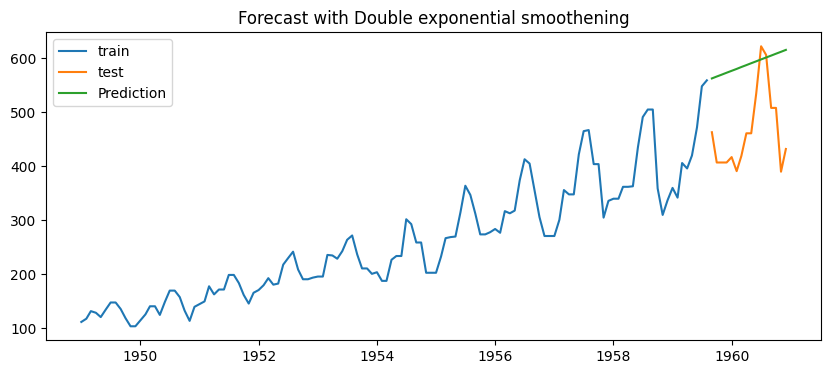

mean absolute error: 127.92
mean absolute percentage error: 30.0%
r2 score: -2.96
root mean squared error: 140.67


In [34]:
model_evaluator(train['#Passengers'].ffill(),test['#Passengers'].ffill(),double_pred, 'Double exponential smoothening')

In [35]:
thriple_smothening= ExponentialSmoothing(train['#Passengers'].ffill(),
                                         seasonal='mul',
                                         trend='mul',
                                         seasonal_periods=12).fit()

In [37]:
thriple_smothening.summary()

Dep. Variable:,#Passengers,No. Observations:,128
Model:,ExponentialSmoothing,SSE,29617.093
Optimized:,True,AIC,728.842
Trend:,Multiplicative,BIC,774.474
Seasonal:,Multiplicative,AICC,735.117
Seasonal Periods:,12,Date:,"Sat, 08 Aug 2026"
Box-Cox:,False,Time:,09:34:39
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.4883635,alpha,True
smoothing_trend,0.000000,beta,True


In [38]:
thriple_pred= thriple_smothening.forecast(len(test))

In [39]:
thriple_pred

1959-09-01    500.460700
1959-10-01    432.751217
1959-11-01    376.192852
1959-12-01    394.987412
1960-01-01    405.559930
1960-02-01    410.182247
1960-03-01    466.041160
1960-04-01    463.568313
1960-05-01    469.927920
1960-06-01    539.322459
1960-07-01    611.960454
1960-08-01    615.173034
1960-09-01    558.134596
1960-10-01    482.622163
1960-11-01    419.545921
1960-12-01    440.506396
Freq: MS, dtype: float64

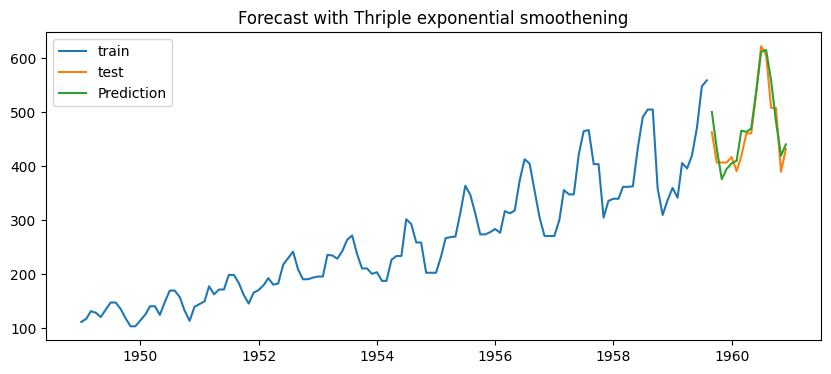

mean absolute error: 20.77
mean absolute percentage error: 5.0%
r2 score: 0.87
root mean squared error: 25.33


In [40]:
model_evaluator(train['#Passengers'].ffill(),test['#Passengers'].ffill(),thriple_pred, 'Thriple exponential smoothening')

In [41]:
test.isnull().sum()

#Passengers       4
month             4
quater            4
lag1              4
lag2              4
lag3              4
lag6              4
lag12             4
rolling_mean3     4
rolling_std3      4
rolling_mean6     4
rolling_std6      4
rolling_mean12    4
rolling_std12     4
dtype: int64

In [42]:
train.isnull().sum()

#Passengers       22
month             22
quater            22
lag1              23
lag2              24
lag3              25
lag6              28
lag12             34
rolling_mean3     24
rolling_std3      24
rolling_mean6     27
rolling_std6      27
rolling_mean12    33
rolling_std12     33
dtype: int64

In [43]:
df.isnull().sum()

#Passengers        0
month              0
quater             0
lag1               1
lag2               2
lag3               3
lag6               6
lag12             12
rolling_mean3      2
rolling_std3       2
rolling_mean6      5
rolling_std6       5
rolling_mean12    11
rolling_std12     11
dtype: int64

In [44]:
df=df.asfreq('MS')

In [49]:
# Predicting the future

final_exponential_smoothening= ExponentialSmoothing(df['#Passengers'].ffill(),
                                                   seasonal='mul',
                                                  trend='mul',
                                                  seasonal_periods=12 ).fit()

In [51]:
final_exponential_smoothening.summary()

Dep. Variable:,#Passengers,No. Observations:,144
Model:,ExponentialSmoothing,SSE,39414.214
Optimized:,True,AIC,840.138
Trend:,Multiplicative,BIC,887.655
Seasonal:,Multiplicative,AICC,845.610
Seasonal Periods:,12,Date:,"Sat, 08 Aug 2026"
Box-Cox:,False,Time:,09:37:07
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.3047050,alpha,True
smoothing_trend,0.000000,beta,True


In [52]:
next_12_months= final_exponential_sommthening.forecast(12)

In [53]:
next_12_months

1961-01-01    443.332337
1961-02-01    441.066650
1961-03-01    495.323327
1961-04-01    503.223173
1961-05-01    508.716622
1961-06-01    585.231869
1961-07-01    667.576067
1961-08-01    666.741543
1961-09-01    587.384614
1961-10-01    525.595203
1961-11-01    455.761605
1961-12-01    479.822043
Freq: MS, dtype: float64

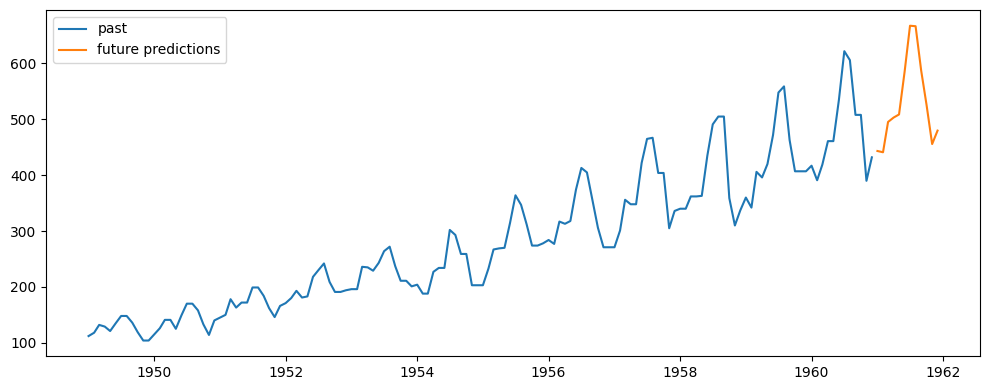

In [54]:
plt.figure(figsize=(10,4))

plt.plot(df['#Passengers'].ffill(), label= 'past')
plt.plot(next_12_months, label='future predictions')

plt.legend()
plt.tight_layout()
plt.show()

In [55]:
joblib.dump(final_exponential_sommthening, r"C:\Users\MINE\Desktop\Air passenger prediction\models\expo_smoothening.pkl")

['C:\\Users\\MINE\\Desktop\\Air passenger prediction\\models\\expo_smoothening.pkl']